# D3 Flood Analysis Workflow — GeoPrompt

Flood exposure screening, raster terrain analysis, and mitigation scenarios.

In [1]:
from __future__ import annotations
import json, os
from pathlib import Path
from urllib.error import URLError
from urllib.request import Request, urlopen
import matplotlib.pyplot as plt

OUTPUT_DIR = Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ALLOW_LIVE_API = os.getenv("GEOPROMPT_ALLOW_LIVE_API", "1") == "1"

def fetch_json(url, fallback):
    if not ALLOW_LIVE_API:
        return fallback
    try:
        req = Request(url, headers={"User-Agent": "geoprompt-notebook/2.0"})
        with urlopen(req, timeout=6) as r:
            return json.loads(r.read().decode("utf-8"))
    except (URLError, TimeoutError, ValueError):
        return fallback

def fetch_first_json(urls, validator, fallback):
    for url in urls:
        payload = fetch_json(url, None)
        if payload is not None and validator(payload):
            return payload, url, True
    return fallback, "fallback", False

import geoprompt as gp
from geoprompt import GeoPromptFrame, write_geojson
from geoprompt.raster import raster_slope_aspect, raster_hillshade, raster_algebra, sample_raster_points
from geoprompt.tools import build_scenario_report, export_scenario_report
print("Imports OK")


Imports OK


## Section A: Pull Data Sources

In [ ]:
flood = {"features": [{"id": "fallback-flood"}]}
weather = {"properties": {"forecast": "fallback"}}
forecast = {"hourly": {"temperature_2m": [0.0]}}

flood, flood_src, flood_live = fetch_first_json(
    [
        "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_day.geojson",
        "https://api.github.com/repos/OSGeo/gdal",
    ],
    lambda d: isinstance(d, dict) and bool(d.get("features") or d.get("id")),
    flood,
)
weather, wx_src, wx_live = fetch_first_json(
    [
        "https://api.weather.gov/points/29.76,-95.37",
        "https://api.weather.gov/points/30.27,-97.74",
    ],
    lambda d: isinstance(d, dict) and bool(d.get("properties", {}).get("forecast")),
    weather,
)
forecast, fc_src, fc_live = fetch_first_json(
    [
        "https://api.open-meteo.com/v1/forecast?latitude=29.76&longitude=-95.37&hourly=temperature_2m&forecast_days=1",
        "https://api.open-meteo.com/v1/forecast?latitude=30.27&longitude=-97.74&hourly=temperature_2m&forecast_days=1",
    ],
    lambda d: isinstance(d, dict) and len(d.get("hourly", {}).get("temperature_2m", [])) > 0,
    forecast,
)

flood_count = len(flood.get("features", [])) if isinstance(flood, dict) else 0
if flood_count == 0 and isinstance(flood, dict) and flood.get("id"):
    flood_count = 1
print(f"Flood records: {flood_count} | live={flood_live} | source={flood_src}")
print(f"NOAA forecast exists: {bool(weather.get('properties', {}).get('forecast'))} | live={wx_live} | source={wx_src}")
print(f"Open-Meteo hourly points: {len(forecast.get('hourly', {}).get('temperature_2m', []))} | live={fc_live} | source={fc_src}")


## Section B: Spatial Analysis

Asset flood risk:
asset_id zone flood_risk_score  expected_loss_musd
      A1    X           0.4127              0.2971
      A2   AE           0.9886              1.3346
      A3   AE           0.9350              0.5386
      A4   VE           1.2085              1.9795
      A5   AE           1.0215              1.0113

Assets in flood zones:
asset_id zone_type
      A1      None
      A2        AE
      A3        AE
      A3        VE
      A4        VE
      A5        AE

Exposure buffers (3km): 5

Nearest flood zone per asset (km):
asset_id zone_id   dist_km
      A1    None       nan
      A2    Z_AE     4.245
      A3    Z_AE     3.949
      A4    Z_VE     1.281
      A5    Z_AE     6.911

Assets within AE zone extent: ['A2', 'A3', 'A5']

Exposure dissolved by zone type:
  AE: replacement_musd=16.2000, flood_risk_score=0.9817
  AE: replacement_musd=16.2000, flood_risk_score=0.9817
  AE: replacement_musd=16.2000, flood_risk_score=0.9817
  VE: replacement_musd=12.3000, flood_risk

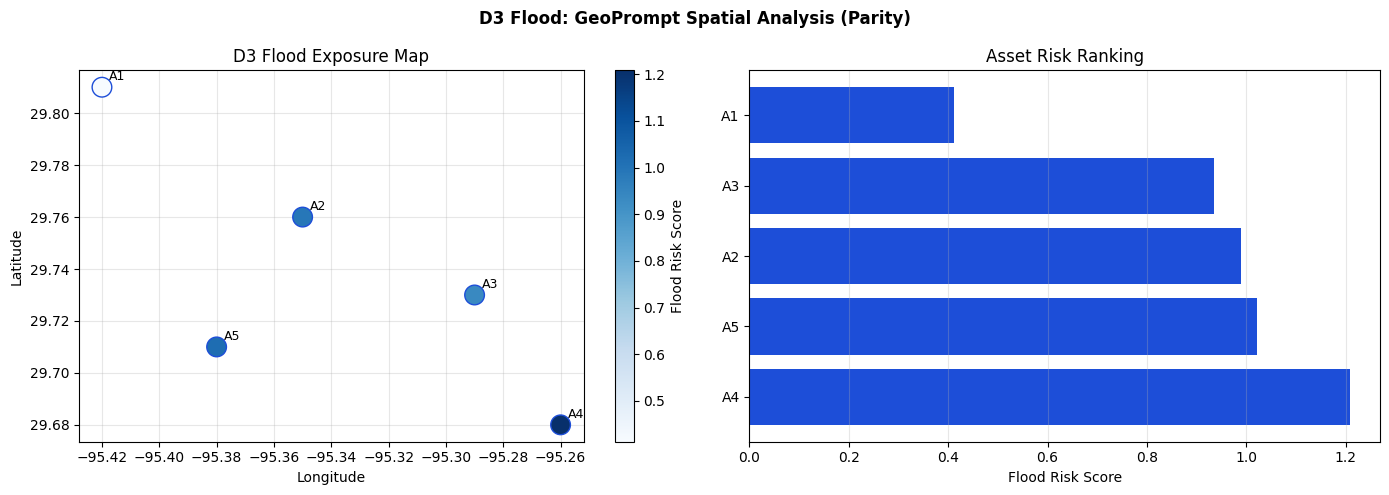


GeoPrompt frame summary (extension):
{
  "row_count": 5,
  "column_count": 7,
  "columns": [
    "asset_id",
    "zone",
    "replacement_musd",
    "elevation_m",
    "geometry",
    "flood_risk_score",
    "expected_loss_musd"
  ],
  "crs": "EPSG:4326",
  "geometry_column": "geometry",
  "geometry_types": [
    "Point"
  ],
  "bounds": {
    "min_x": -95.42,
    "min_y": 29.68,
    "max_x": -95.26,
    "max_y": 29.81
  },
  "column_stats": [
    {
      "column": "asset_id",
      "dtype": "string",
      "null_count": 0,
      "unique_count": 5
    },
    {
      "column": "zone",
      "dtype": "string",
      "null_count": 0,
      "unique_count": 3
    },
    {
      "column": "replacement_musd",
      "dtype": "numeric",
      "null_count": 0,
      "unique_count": 5,
      "min": 3.2,
      "max": 9.1,
      "mean": 5.86
    },
    {
      "column": "elevation_m",
      "dtype": "numeric",
      "null_count": 0,
      "unique_count": 5,
      "min": 5.9,
      "max": 11.0,
   

In [3]:
RAW_ASSETS = [
    {"asset_id": "A1", "zone": "X",  "replacement_musd": 4.0, "elevation_m": 11.0,
     "geometry": {"type": "Point", "coordinates": [-95.42, 29.81]}},
    {"asset_id": "A2", "zone": "AE", "replacement_musd": 7.5, "elevation_m": 7.0,
     "geometry": {"type": "Point", "coordinates": [-95.35, 29.76]}},
    {"asset_id": "A3", "zone": "AE", "replacement_musd": 3.2, "elevation_m": 8.0,
     "geometry": {"type": "Point", "coordinates": [-95.29, 29.73]}},
    {"asset_id": "A4", "zone": "VE", "replacement_musd": 9.1, "elevation_m": 5.9,
     "geometry": {"type": "Point", "coordinates": [-95.26, 29.68]}},
    {"asset_id": "A5", "zone": "AE", "replacement_musd": 5.5, "elevation_m": 6.5,
     "geometry": {"type": "Point", "coordinates": [-95.38, 29.71]}},
]
ZONE_RISK = {"VE": 1.0, "AE": 0.8, "X": 0.2}

enriched = []
for row in RAW_ASSETS:
    zone_risk = ZONE_RISK.get(str(row["zone"]), 0.3)
    elev = float(row["elevation_m"])
    risk = round(zone_risk * 0.7 + (10.0 / elev) * 0.3, 4)
    loss = round(float(row["replacement_musd"]) * risk * 0.18, 4)
    enriched.append({**row, "flood_risk_score": risk, "expected_loss_musd": loss})

assets_frame = GeoPromptFrame(enriched, geometry_column="geometry", crs="EPSG:4326")
print("Asset flood risk:")
print(f"{'asset_id':>8} {'zone':>4} {'flood_risk_score':>16} {'expected_loss_musd':>19}")
for row in assets_frame.to_records():
    print(f"{str(row['asset_id']):>8} {str(row['zone']):>4} {float(row['flood_risk_score']):16.4f} {float(row['expected_loss_musd']):19.4f}")

flood_zone_rows = [
    {
        "zone_id": "Z_AE",
        "zone_type": "AE",
        "geometry": {"type": "Polygon", "coordinates": [[[-95.40, 29.69], [-95.25, 29.69], [-95.25, 29.78], [-95.40, 29.78], [-95.40, 29.69]]]},
    },
    {
        "zone_id": "Z_VE",
        "zone_type": "VE",
        "geometry": {"type": "Polygon", "coordinates": [[[-95.30, 29.65], [-95.22, 29.65], [-95.22, 29.73], [-95.30, 29.73], [-95.30, 29.65]]]},
    },
]
flood_zones = GeoPromptFrame(flood_zone_rows, geometry_column="geometry", crs="EPSG:4326")

# 1. Spatial join: assets within flood zones
in_zone = assets_frame.spatial_join(flood_zones, how="left", predicate="within")
print("\nAssets in flood zones:")
print(f"{'asset_id':>8} {'zone_type':>9}")
for row in in_zone.to_records():
    print(f"{str(row.get('asset_id')):>8} {str(row.get('zone_type')):>9}")

# 2. Buffer: flood exposure buffers around assets (3 km projected)
assets_proj = assets_frame.to_crs("EPSG:3857")
buffers = assets_proj.buffer(3000).to_crs("EPSG:4326")
print(f"\nExposure buffers (3km): {len(buffers)}")

# 3. Nearest join: assign each asset to nearest zone centroid (km)
zone_centers = GeoPromptFrame(
    [
        {"zone_id": "Z_AE", "geometry": {"type": "Point", "coordinates": [-95.325, 29.735]}},
        {"zone_id": "Z_VE", "geometry": {"type": "Point", "coordinates": [-95.260, 29.690]}},
    ],
    geometry_column="geometry",
    crs="EPSG:4326",
)
nearest = zone_centers.to_crs("EPSG:3857").assign_nearest(assets_proj, how="left", distance_method="euclidean")
nearest_rows = sorted(nearest.to_records(), key=lambda r: str(r.get("asset_id")))
print("\nNearest flood zone per asset (km):")
print(f"{'asset_id':>8} {'zone_id':>7} {'dist_km':>9}")
for row in nearest_rows:
    dist_val = row.get("distance_origin")
    dist_km = (float(dist_val) / 1000.0) if dist_val is not None else float('nan')
    print(f"{str(row.get('asset_id')):>8} {str(row.get('zone_id')):>7} {dist_km:9.3f}")

# 4. Assets within AE zone extent
ae_zone = GeoPromptFrame([r for r in flood_zone_rows if r["zone_type"] == "AE"], geometry_column="geometry", crs="EPSG:4326")
in_ae = assets_frame.spatial_join(ae_zone, how="inner", predicate="within")
print(f"\nAssets within AE zone extent: {[r['asset_id'] for r in in_ae.to_records()]}")

# 5. Dissolve: total exposure by zone type
in_zone_rows = [r for r in in_zone.to_records() if r.get("zone_type") is not None]
if in_zone_rows:
    in_zone_clean = GeoPromptFrame(in_zone_rows, geometry_column="geometry", crs="EPSG:4326")
    dissolved = in_zone_clean.dissolve(by="zone_type", aggregations={"replacement_musd": "sum", "flood_risk_score": "mean"})
    print("\nExposure dissolved by zone type:")
    for row in dissolved.to_records():
        loss_sum = row.get("replacement_musd_sum_zone_type", row.get("replacement_musd", 0.0))
        risk_mean = row.get("flood_risk_score_mean_zone_type", row.get("flood_risk_score", 0.0))
        print(f"  {row['zone_type']}: replacement_musd={float(loss_sum):.4f}, flood_risk_score={float(risk_mean):.4f}")

# 6. Bounding box filter
high_risk_area = assets_frame.query_bounds(-95.40, 29.68, -95.25, 29.78)
print(f"\nAssets in high-risk area: {[r['asset_id'] for r in high_risk_area.to_records()]}")

# 7. Overlay-style intersection count: 5km asset buffers vs flood zones
asset_buffers_5km = assets_proj.buffer(5000).to_crs("EPSG:4326")
overlapping = asset_buffers_5km.spatial_join(flood_zones, how="inner", predicate="intersects")
print(f"\nBuffer-zone intersections: {len(overlapping)} areas")

write_geojson(OUTPUT_DIR / "d3-gp-assets.geojson", assets_frame)
print("\nWrote d3-gp-assets.geojson")

# Visualization
records = assets_frame.to_records()
lons = [float(r["geometry"]["coordinates"][0]) for r in records]
lats = [float(r["geometry"]["coordinates"][1]) for r in records]
risks = [float(r["flood_risk_score"]) for r in records]
asset_ids = [str(r["asset_id"]) for r in records]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = axes[0].scatter(lons, lats, c=risks, cmap="Blues", s=200, edgecolors="#1d4ed8", zorder=5)
for lon, lat, aid in zip(lons, lats, asset_ids):
    axes[0].annotate(aid, (lon, lat), textcoords="offset points", xytext=(5, 5), fontsize=9)
plt.colorbar(sc, ax=axes[0], label="Flood Risk Score")
axes[0].set_title("D3 Flood Exposure Map")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
axes[0].grid(True, alpha=0.3)

sorted_recs = sorted(records, key=lambda r: -float(r["flood_risk_score"]))
axes[1].barh([r["asset_id"] for r in sorted_recs], [float(r["flood_risk_score"]) for r in sorted_recs], color="#1d4ed8")
axes[1].set_xlabel("Flood Risk Score"); axes[1].set_title("Asset Risk Ranking")
axes[1].grid(True, axis="x", alpha=0.3)
plt.suptitle("D3 Flood: GeoPrompt Spatial Analysis (Parity)", fontweight="bold")
plt.tight_layout(); plt.show()

print("\nGeoPrompt frame summary (extension):")
print(json.dumps(assets_frame.summary(), indent=2, default=str))


## Section C: Scenario Comparison

Scenario report: d:\Github\geoprompt\examples\notebooks\geoprompt\outputs\d3-gp-scenario-report.json

=== GeoPrompt-only extension: raster analysis ===
Slope grid center value: 12.3744
Hillshade grid center value: 0.00
Combined raster center value: 1.800

Sampled flood depths at asset locations:
  A1: flood_depth_m=0.400
  A2: flood_depth_m=2.000
  A3: flood_depth_m=1.900
  A4: flood_depth_m=1.000
  A5: flood_depth_m=0.700


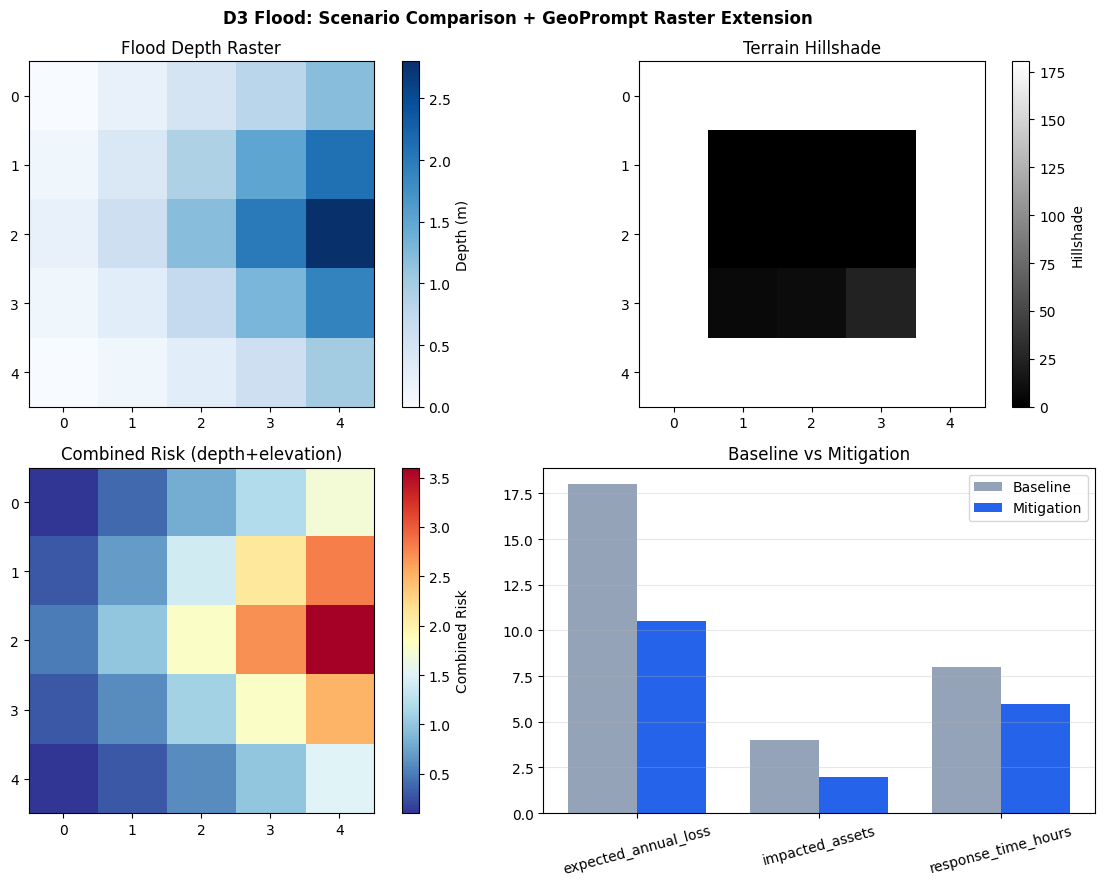

Wrote d3-gp-complex.json


In [4]:
baseline   = {"expected_annual_loss": 18.0, "impacted_assets": 4, "response_time_hours": 8.0}
mitigation = {"expected_annual_loss": 10.5, "impacted_assets": 2, "response_time_hours": 6.0}
report = build_scenario_report(baseline, mitigation, higher_is_better=[])
report_path = export_scenario_report(report, OUTPUT_DIR / "d3-gp-scenario-report.json")
print("Scenario report:", report_path)

print("\n=== GeoPrompt-only extension: raster analysis ===")
# Define a 5x5 raster grid (same transform for algebra operations)
RASTER_TRANSFORM = (-95.50, 29.90, 0.05, 0.05)  # (min_x, max_y, cell_w, cell_h)

# Flood depth raster (simulated inundation depths in meters)
flood_depth_raster = {
    "data": [
        [0.0, 0.2, 0.5, 0.8, 1.2],
        [0.1, 0.4, 0.9, 1.5, 2.1],
        [0.2, 0.6, 1.2, 2.0, 2.8],
        [0.1, 0.3, 0.7, 1.3, 1.9],
        [0.0, 0.1, 0.3, 0.6, 1.0],
    ],
    "transform": RASTER_TRANSFORM,
}

# Elevation risk raster (higher elevation = lower risk)
elevation_raster = {
    "data": [
        [0.1, 0.2, 0.3, 0.4, 0.5],
        [0.2, 0.3, 0.5, 0.6, 0.7],
        [0.3, 0.4, 0.6, 0.7, 0.8],
        [0.2, 0.3, 0.4, 0.5, 0.6],
        [0.1, 0.2, 0.3, 0.4, 0.5],
    ],
    "transform": RASTER_TRANSFORM,
}

slope_data = raster_slope_aspect(flood_depth_raster)
print(f"Slope grid center value: {slope_data['slope'][2][2]:.4f}")
hillshade_data = raster_hillshade(flood_depth_raster)
print(f"Hillshade grid center value: {hillshade_data['grid'][2][2]:.2f}")
combined_raster = raster_algebra(flood_depth_raster, elevation_raster, operation="add")
print(f"Combined raster center value: {combined_raster['data'][2][2]:.3f}")

sampled_frame = sample_raster_points(flood_depth_raster, assets_frame, value_column="flood_depth_m")
print("\nSampled flood depths at asset locations:")
for row in sampled_frame.to_records():
    print(f"  {row['asset_id']}: flood_depth_m={row['flood_depth_m']:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Flood depth raster
im0 = axes[0][0].imshow(flood_depth_raster["data"], cmap="Blues", origin="upper")
plt.colorbar(im0, ax=axes[0][0], label="Depth (m)"); axes[0][0].set_title("Flood Depth Raster")

# Hillshade
im1 = axes[0][1].imshow(hillshade_data["grid"], cmap="gray", origin="upper")
plt.colorbar(im1, ax=axes[0][1], label="Hillshade"); axes[0][1].set_title("Terrain Hillshade")

# Combined raster
im2 = axes[1][0].imshow(combined_raster["data"], cmap="RdYlBu_r", origin="upper")
plt.colorbar(im2, ax=axes[1][0], label="Combined Risk"); axes[1][0].set_title("Combined Risk (depth+elevation)")

# Scenario comparison
metrics = list(baseline.keys())
x = range(len(metrics))
width = 0.38
axes[1][1].bar([i - width/2 for i in x], [float(baseline[m]) for m in metrics], width=width, label="Baseline", color="#94a3b8")
axes[1][1].bar([i + width/2 for i in x], [float(mitigation[m]) for m in metrics], width=width, label="Mitigation", color="#2563eb")
axes[1][1].set_xticks(list(x)); axes[1][1].set_xticklabels(metrics, rotation=15)
axes[1][1].set_title("Baseline vs Mitigation"); axes[1][1].legend(); axes[1][1].grid(True, axis="y", alpha=0.3)

plt.suptitle("D3 Flood: Scenario Comparison + GeoPrompt Raster Extension", fontweight="bold")
plt.tight_layout(); plt.show()

(OUTPUT_DIR / "d3-gp-complex.json").write_text(
    json.dumps({"slope_center": slope_data["slope"][2][2], "hillshade_center": hillshade_data["grid"][2][2],
                "combined_center": combined_raster["data"][2][2]}, indent=2, default=str), encoding="utf-8"
)
print("Wrote d3-gp-complex.json")
